<a href="https://colab.research.google.com/github/AureliaVDB/TickIt_Data_Pipeline/blob/main/TickIt_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medallion Architecture Data Pipeline: Event Ticketing Analytics
Aurelia Vandenbosch

## Environment Setup

In [1]:
# installing packages
!pip install pyspark -q
!pip install delta-spark -q

In [2]:
# importing libraries
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import IntegerType, TimestampType, BooleanType, DataType, DecimalType
import os, glob, shutil
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

In [3]:
from pyspark.sql import SparkSession
from delta import configure_spark_with_delta_pip

# Configure Spark builder with Delta Lake configurations
builder = (
    SparkSession.builder
    .appName("TickIt_Medallion_Pipeline")
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension")
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")
)

# Automatically attach Delta Lake JARs and start the session
spark = configure_spark_with_delta_pip(builder).getOrCreate()

In [4]:
# connecting to drive
from google.colab import drive

drive.mount("/content/drive")

BASE = "/content/drive/MyDrive/TickIt_Project"

# creating files in drive

RAW = f"{BASE}/raw"  # csv files
BRONZE = f"{BASE}/bronze"  # storage for bronze layer
SILVER = f"{BASE}/silver"  # storage for silver layer
GOLD = f"{BASE}/gold"  # storage for gold layer

for path in [RAW, BRONZE, SILVER, GOLD]:
    os.makedirs(path, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Bronze Layer
- Load all CSVs
- Store as Parquet
- Show schema, row count, sample records

In [5]:
# list of all the source files
raw_files = []
for f in os.listdir(RAW):
    if f.endswith(".csv"):
        raw_files.append(f)

print(f"files in list: {raw_files}")

files in list: ['orders.csv', 'payments.csv', 'events.csv', 'event_categories.csv', 'ticket_types.csv', 'customers.csv', 'reviews.csv']


In [6]:
# loop through raw files and save them to bronze
for file in raw_files:
  input_path = os.path.join(RAW, file)
  table_name = os.path.splitext(file)[0]
  output_path = os.path.join(BRONZE, table_name)

  # read csv and write parquet
  df = spark.read.csv(input_path, header=True)
  df.write.mode("overwrite").parquet(output_path)

  # show table info
  print(f"{table_name.upper()}")
  print()
  print("Schema")
  df.printSchema()
  print(f"Row Count: {df.count()}")
  print()
  print("Sample Records")
  df.show(5)
  print()

ORDERS

Schema
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- event_id: string (nullable = true)
 |-- ticket_type_id: string (nullable = true)
 |-- order_date: string (nullable = true)
 |-- event_date: string (nullable = true)
 |-- quantity: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- promo_code: string (nullable = true)

Row Count: 52520

Sample Records
+--------------+----------------+--------+--------------+-------------------+----------+--------+------------+----------+
|      order_id|     customer_id|event_id|ticket_type_id|         order_date|event_date|quantity|order_status|promo_code|
+--------------+----------------+--------+--------------+-------------------+----------+--------+------------+----------+
|    ORD0039854|b2744cf668394fac| EVT0050|       TT00106|2022-08-15 10:00:00|2022-09-03|       2|   completed|      NULL|
|    ORD0002676|ad9181b36ee84121| EVT0092|       TT00194|2021-04-15 23:00:00|20

## Silver Layer
Cleaning and preparing the raw Bronze data:
- Fix data types (dates, numbers, text)
- Remove duplicate rows
- Clean up text (lowercase emails, trim spaces)
- Check for missing or bad values

In [7]:
# load all bronze parquet tables into a dictionary
bronze_tables = {}

for folder_name in os.listdir(BRONZE):
  folder_path = os.path.join(BRONZE, folder_name)
  if os.path.isdir(folder_path):
    bronze_tables[folder_name] = spark.read.parquet(folder_path)


### Orders

In [8]:
# get raw orders from bronze and check schema + data
orders_raw = bronze_tables["orders"]

orders_raw.printSchema()

orders_raw.show(5)

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- event_id: string (nullable = true)
 |-- ticket_type_id: string (nullable = true)
 |-- order_date: string (nullable = true)
 |-- event_date: string (nullable = true)
 |-- quantity: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- promo_code: string (nullable = true)

+--------------+----------------+--------+--------------+-------------------+----------+--------+------------+----------+
|      order_id|     customer_id|event_id|ticket_type_id|         order_date|event_date|quantity|order_status|promo_code|
+--------------+----------------+--------+--------------+-------------------+----------+--------+------------+----------+
|    ORD0039854|b2744cf668394fac| EVT0050|       TT00106|2022-08-15 10:00:00|2022-09-03|       2|   completed|      NULL|
|    ORD0002676|ad9181b36ee84121| EVT0092|       TT00194|2021-04-15 23:00:00|2021-06-30|       6|   completed|      NULL|
|    

**Data Decisions for Orders:**
* `quantity`: Cast to integer because ticket counts cannot be fractional.
* `order_date`: Converted to timestamp to preserve exact transaction timing.
* `event_date`: Converted to date format since event schedules are tracked daily.

In [9]:
orders_cleaned = (
    orders_raw.withColumn("quantity", F.col("quantity").cast(IntegerType()))
    .withColumn("order_date", F.to_timestamp(F.col("order_date")))
    .withColumn("event_date", F.to_date(F.col("event_date")))
)

orders_cleaned.printSchema()
orders_cleaned.show(5, truncate=False)

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- event_id: string (nullable = true)
 |-- ticket_type_id: string (nullable = true)
 |-- order_date: timestamp (nullable = true)
 |-- event_date: date (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- order_status: string (nullable = true)
 |-- promo_code: string (nullable = true)

+--------------+----------------+--------+--------------+-------------------+----------+--------+------------+----------+
|order_id      |customer_id     |event_id|ticket_type_id|order_date         |event_date|quantity|order_status|promo_code|
+--------------+----------------+--------+--------------+-------------------+----------+--------+------------+----------+
|ORD0039854    |b2744cf668394fac|EVT0050 |TT00106       |2022-08-15 10:00:00|2022-09-03|2       |completed   |NULL      |
|ORD0002676    |ad9181b36ee84121|EVT0092 |TT00194       |2021-04-15 23:00:00|2021-06-30|6       |completed   |NULL      |
|OR

**Data Quality Check:**
* Check for null / missing values

In [10]:
orders_cleaned.select(
    [
        F.count(F.when(F.col(c).isNull(), c)).alias(c)
        for c in [
            "order_id",
            "customer_id",
            "event_id",
            "ticket_type_id",
            "order_date",
            "quantity",
            "promo_code",
        ]
    ]
).show()

+--------+-----------+--------+--------------+----------+--------+----------+
|order_id|customer_id|event_id|ticket_type_id|order_date|quantity|promo_code|
+--------+-----------+--------+--------------+----------+--------+----------+
|       0|        270|       0|             0|         0|       0|     29352|
+--------+-----------+--------+--------------+----------+--------+----------+



**Handling Missing Customer IDs:**
* Check rows where `customer_id` is null.
* Orders missing a customer ID cannot be linked to customer dimensions.

In [11]:

missing_customers = orders_cleaned.filter(F.col("customer_id").isNull())

print(f"Total rows with missing customer_id: {missing_customers.count()}")
missing_customers.show(10, truncate=False)


Total rows with missing customer_id: 270
+----------+-----------+--------+--------------+-------------------+----------+--------+------------+----------+
|order_id  |customer_id|event_id|ticket_type_id|order_date         |event_date|quantity|order_status|promo_code|
+----------+-----------+--------+--------------+-------------------+----------+--------+------------+----------+
|ORD0037574|NULL       |EVT0181 |TT00366       |2022-04-12 06:00:00|2022-04-20|4       |completed   |NULL      |
|ORD0003884|NULL       |EVT0340 |TT00705       |2022-10-17 19:00:00|2022-11-13|4       |completed   |STUDENT15 |
|ORD0037061|NULL       |EVT0408 |TT00835       |2025-04-18 08:00:00|2025-05-08|1       |completed   |NULL      |
|ORD0008603|NULL       |EVT0256 |TT00532       |2022-10-30 04:00:00|2022-12-06|2       |completed   |NULL      |
|ORD0012328|NULL       |EVT0118 |TT00240       |2022-06-01 17:00:00|2022-06-16|1       |completed   |NULL      |
|ORD0043240|NULL       |EVT0240 |TT00492       |2024-12

**Duplicate Check:**
* Verify uniqueness of `order_id`, maybe that's why there are customers IDs null.

In [12]:
total_orders = orders_cleaned.count()
distinct_orders = orders_cleaned.select("order_id").distinct().count()

print(f"Duplicates in order id: {total_orders - distinct_orders}")

Duplicates in order id: 0


**Handling Missing `customer_id` (Guest Checkout Decision):**
- no duplicates in order_id
- Can't drop the rows without `customer_id`, because there is valid tickets in these rows
- on many websites, you can book tickets as guest

In [13]:
orders_silver = orders_cleaned.fillna({"customer_id": "GUEST"})

#verify
orders_silver.select(
    [
        F.count(F.when(F.col(c).isNull(), c)).alias(c)
        for c in ["order_id", "customer_id", "quantity", "promo_code"]
    ]
).show()

+--------+-----------+--------+----------+
|order_id|customer_id|quantity|promo_code|
+--------+-----------+--------+----------+
|       0|          0|       0|     29352|
+--------+-----------+--------+----------+



- check quantity for unrealistic numbers

In [14]:
orders_silver.select("quantity").describe().show()

quantiles = orders_silver.approxQuantile(
    "quantity", [0.25, 0.50, 0.75, 0.95, 0.99, 1.0], 0.01
)
print("Percentiles [25%, 50%, 75%, 95%, 99%, Max]:", quantiles)

+-------+------------------+
|summary|          quantity|
+-------+------------------+
|  count|             52520|
|   mean| 2.547981721249048|
| stddev|1.3551327100983674|
|    min|                 0|
|    max|                 6|
+-------+------------------+

Percentiles [25%, 50%, 75%, 95%, 99%, Max]: [2.0, 2.0, 3.0, 5.0, 6.0, 6.0]


**Checking Flagged Duplicate IDs:**
* Inspect records containing `_DUP` in `order_id` to identify dirty data or duplicates

In [15]:
dup_orders = orders_silver.filter(F.col("order_id").contains("_DUP"))

print(f"Total records with '_DUP' in order_id: {dup_orders.count()}")
dup_orders.show(10, truncate=False)

Total records with '_DUP' in order_id: 520
+--------------+----------------+--------+--------------+-------------------+----------+--------+------------+----------+
|order_id      |customer_id     |event_id|ticket_type_id|order_date         |event_date|quantity|order_status|promo_code|
+--------------+----------------+--------+--------------+-------------------+----------+--------+------------+----------+
|ORD0048203_DUP|1e2a435ad7c74203|EVT0160 |TT00325       |2022-03-20 09:00:00|2022-04-02|1       |completed   |NULL      |
|ORD0027374_DUP|e771cb9cbded4054|EVT0076 |TT00155       |2024-03-04 22:00:00|2024-05-31|1       |completed   |NULL      |
|ORD0003043_DUP|bfc8ed144bd74aa8|EVT0240 |TT00492       |2024-07-20 23:00:00|2024-08-17|2       |completed   |SUMMER10  |
|ORD0022897_DUP|c844312a9119439f|EVT0067 |TT00135       |2024-10-03 16:00:00|2024-10-08|1       |completed   |NULL      |
|ORD0021446_DUP|25d94a5b1da34368|EVT0301 |TT00625       |2023-05-29 04:00:00|2023-06-05|6       |comple

**Inspect Duplicate vs Original Record:**
check if the details are the same

In [16]:
orders_silver.filter(
    (F.col("order_id") == "ORD0048203") | (F.col("order_id") == "ORD0048203_DUP")
).show(truncate=False)

+--------------+----------------+--------+--------------+-------------------+----------+--------+------------+----------+
|order_id      |customer_id     |event_id|ticket_type_id|order_date         |event_date|quantity|order_status|promo_code|
+--------------+----------------+--------+--------------+-------------------+----------+--------+------------+----------+
|ORD0048203_DUP|1e2a435ad7c74203|EVT0160 |TT00325       |2022-03-20 09:00:00|2022-04-02|1       |completed   |NULL      |
|ORD0048203    |1e2a435ad7c74203|EVT0160 |TT00325       |2022-03-20 09:00:00|2022-04-02|1       |completed   |NULL      |
+--------------+----------------+--------+--------------+-------------------+----------+--------+------------+----------+



**Fixing Duplicate Order IDs:**
- Strip the `_DUP` suffix to restore original order IDs.
- Deduplicate on `order_id` so each transaction only appears once.
- Not just drop, in case these are DUPs without original

In [17]:
orders_silver = orders_silver.withColumn(
    "order_id", F.regexp_replace(F.col("order_id"), "_DUP", "")
)

orders_silver = orders_silver.dropDuplicates(["order_id"])


**Check Order Status Values:**
* Inspect distinct values in `order_status` to spot any typos, inconsistent casing, or unexpected categories.

In [18]:
orders_silver.groupBy("order_status").count().orderBy(
    F.col("count").desc()
).show(truncate=False)

+------------+-----+
|order_status|count|
+------------+-----+
|completed   |38223|
|cancelled   |8042 |
|confirmed   |3176 |
|no_show     |2559 |
+------------+-----+



In [19]:
#Save cleaned orders to silver layer
orders_silver_path = os.path.join(SILVER, "orders")
orders_silver.write.mode("overwrite").parquet(orders_silver_path)

### Customers

In [20]:
# get raw customers from bronze and check schema + data
customers_raw = bronze_tables["customers"]

customers_raw.printSchema()

customers_raw.show(5, truncate=False)

root
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- first_name: string (nullable = true)
 |-- last_name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- city: string (nullable = true)
 |-- country_code: string (nullable = true)
 |-- country: string (nullable = true)
 |-- registration_date: string (nullable = true)
 |-- date_of_birth: string (nullable = true)

+----------------+--------------------------------+----------+---------+-------------------------+-------+------------+--------------+-----------------+-------------+
|customer_id     |customer_unique_id              |first_name|last_name|email                    |city   |country_code|country       |registration_date|date_of_birth|
+----------------+--------------------------------+----------+---------+-------------------------+-------+------------+--------------+-----------------+-------------+
|7ff8bab402524574|4988c52bf1bf47f2b6e3ef3fe0eeb9d3|Simon     |Torre

**Fixing date**
* `registration_date` & `date_of_birth` come in mixed formats (`DD/MM/YYYY` or `DD-MM-YYYY`).
* Replace slashes with dashes and rearrange day/month/year to standard `YYYY-MM-DD` so Spark parses them cleanly into `DateType`.

In [21]:
customers_cleaned = (
     customers_raw
     .withColumn(
        "registration_date",
        F.to_date(
            F.regexp_replace(
                F.regexp_replace(F.col("registration_date"), "/", "-"), # dates are often written with /
                r"^(\d{2})-(\d{2})-(\d{4})$",
                r"$3-$2-$1"
            )
        )
    )
    .withColumn(
        "date_of_birth",
        F.to_date(
            F.regexp_replace(
                F.regexp_replace(F.col("date_of_birth"), "/", "-"),
                r"^(\d{2})-(\d{2})-(\d{4})$",
                r"$3-$2-$1"
            )
        )
    )
)
customers_cleaned.printSchema()

root
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- first_name: string (nullable = true)
 |-- last_name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- city: string (nullable = true)
 |-- country_code: string (nullable = true)
 |-- country: string (nullable = true)
 |-- registration_date: date (nullable = true)
 |-- date_of_birth: date (nullable = true)



**Customer ID Uniqueness & Null Check:**
* Verify total rows against distinct `customer_id` and `customer_unique_id`.
* Check if there are any missing/null customer IDs.

In [22]:
customers_cleaned.select(
    F.count("*").alias("total_rows"),
    F.count_distinct("customer_id").alias("distinct_customer_ids"),
    F.count_distinct("customer_unique_id").alias("distinct_unique_ids"),
    F.sum(F.when(F.col("customer_id").isNull(), 1).otherwise(0)).alias("null_customer_ids")
).show()

+----------+---------------------+-------------------+-----------------+
|total_rows|distinct_customer_ids|distinct_unique_ids|null_customer_ids|
+----------+---------------------+-------------------+-----------------+
|     10800|                10800|              10692|                0|
+----------+---------------------+-------------------+-----------------+



**Standardize Text Fields:**
* Trim whitespace from names, location fields, and email.
* Lowercase emails so joins/lookups aren't broken by mixed caps.
* Uppercase `country_code` for standard 2-letter format.

In [23]:

customers_silver = (
    customers_cleaned
    .withColumn("first_name", F.trim(F.col("first_name")))
    .withColumn("last_name", F.trim(F.col("last_name")))
    .withColumn("email", F.lower(F.trim(F.col("email"))))
    .withColumn("city", F.trim(F.col("city")))
    .withColumn("country", F.trim(F.col("country")))
    .withColumn("country_code", F.upper(F.trim(F.col("country_code"))))
)


In [24]:
# Save cleaned customer table to Silver layer
customers_silver_path = os.path.join(SILVER, "customers")
customers_silver.write.mode("overwrite").parquet(customers_silver_path)

### Events

In [25]:
# get raw events from bronze and check schema + data
events_raw = bronze_tables["events"]

events_raw.printSchema()

events_raw.show(5, truncate=False)

root
 |-- event_id: string (nullable = true)
 |-- event_name: string (nullable = true)
 |-- event_type: string (nullable = true)
 |-- category: string (nullable = true)
 |-- venue_name: string (nullable = true)
 |-- venue_capacity: string (nullable = true)
 |-- city: string (nullable = true)
 |-- country_code: string (nullable = true)
 |-- country: string (nullable = true)
 |-- organizer_since: string (nullable = true)
 |-- is_active: string (nullable = true)

+--------+--------------------+----------+--------+------------------+--------------+---------+------------+-----------+---------------+---------+
|event_id|event_name          |event_type|category|venue_name        |venue_capacity|city     |country_code|country    |organizer_since|is_active|
+--------+--------------------+----------+--------+------------------+--------------+---------+------------+-----------+---------------+---------+
|EVT0001 |Midnight Festival   |Festival  |5       |Innsbruck Grounds |36761         |Innsbruck

**Data Decisions for Events:**
* `venue_capacity`: Cast to integer because venue seating/capacity is a whole number count.
* `organizer_since`: Converted to date format.
* `is_active`: Cast to boolean for binary status flags.

In [26]:
events_cleaned = (
    events_raw
    .withColumn("venue_capacity", F.col("venue_capacity").cast(IntegerType()))
    .withColumn("organizer_since", F.to_date(F.col("organizer_since")))
    .withColumn("is_active", F.col("is_active").cast(BooleanType()))
)

events_cleaned.printSchema()

root
 |-- event_id: string (nullable = true)
 |-- event_name: string (nullable = true)
 |-- event_type: string (nullable = true)
 |-- category: string (nullable = true)
 |-- venue_name: string (nullable = true)
 |-- venue_capacity: integer (nullable = true)
 |-- city: string (nullable = true)
 |-- country_code: string (nullable = true)
 |-- country: string (nullable = true)
 |-- organizer_since: date (nullable = true)
 |-- is_active: boolean (nullable = true)



Check cities

In [27]:

events_raw.select("city").distinct().orderBy("city").show(100, truncate=False)

+----------+
|city      |
+----------+
|ANTWERP   |
|Amsterdam |
|Antwerp   |
|BARCELONA |
|BASEL     |
|BERLIN    |
|BIRMINGHAM|
|BOLOGNA   |
|BRAGA     |
|Barcelona |
|Basel     |
|Berlin    |
|Bern      |
|Bilbao    |
|Birmingham|
|Bologna   |
|Braga     |
|Bruges    |
|Brussels  |
|COLOGNE   |
|Coimbra   |
|Cologne   |
|EINDHOVEN |
|Eindhoven |
|FRANKFURT |
|Faro      |
|Frankfurt |
|GENEVA    |
|GHENT     |
|Ghent     |
|Glasgow   |
|Graz      |
|Groningen |
|Hamburg   |
|Innsbruck |
|LILLE     |
|LYON      |
|Liege     |
|Lille     |
|Linz      |
|Lisbon    |
|Liverpool |
|London    |
|Lyon      |
|MADRID    |
|MANCHESTER|
|MARSEILLE |
|MILAN     |
|Madrid    |
|Manchester|
|Marseille |
|Milan     |
|Munich    |
|NAPLES    |
|Naples    |
|PARIS     |
|PORTO     |
|Paris     |
|Porto     |
|ROME      |
|Rome      |
|Rotterdam |
|STRASBOURG|
|Salzburg  |
|Seville   |
|Strasbourg|
|TURIN     |
|Turin     |
|Utrecht   |
|Valencia  |
|Vienna    |
|Zurich    |
|amsterdam |
|barcelona |

In [28]:
# 1. Standardize city
events_cleaned = events_cleaned.withColumn("city", F.initcap(F.trim(F.col("city"))))

# 2. Verify unique standardized cities
events_cleaned.select("city").distinct().orderBy("city").show(100, truncate=False)

+----------+
|city      |
+----------+
|Amsterdam |
|Antwerp   |
|Barcelona |
|Basel     |
|Berlin    |
|Bern      |
|Bilbao    |
|Birmingham|
|Bologna   |
|Braga     |
|Bruges    |
|Brussels  |
|Coimbra   |
|Cologne   |
|Eindhoven |
|Faro      |
|Frankfurt |
|Geneva    |
|Ghent     |
|Glasgow   |
|Graz      |
|Groningen |
|Hamburg   |
|Innsbruck |
|Liege     |
|Lille     |
|Linz      |
|Lisbon    |
|Liverpool |
|London    |
|Lyon      |
|Madrid    |
|Manchester|
|Marseille |
|Milan     |
|Munich    |
|Naples    |
|Paris     |
|Porto     |
|Rome      |
|Rotterdam |
|Salzburg  |
|Seville   |
|Strasbourg|
|Turin     |
|Utrecht   |
|Valencia  |
|Vienna    |
|Zurich    |
+----------+



**Standardize Text Fields in Events:**
* Trim whitespace
* Uppercase `country_code` to ensure standard format.

In [29]:
events_cleaned = (
    events_cleaned
    .withColumn("event_name", F.trim(F.col("event_name")))
    .withColumn("event_type", F.trim(F.col("event_type")))
    .withColumn("venue_name", F.trim(F.col("venue_name")))
    .withColumn("country", F.trim(F.col("country")))
    .withColumn("country_code", F.upper(F.trim(F.col("country_code"))))
)

events_cleaned.show(5, truncate=False)

+--------+--------------------+----------+--------+------------------+--------------+---------+------------+-----------+---------------+---------+
|event_id|event_name          |event_type|category|venue_name        |venue_capacity|city     |country_code|country    |organizer_since|is_active|
+--------+--------------------+----------+--------+------------------+--------------+---------+------------+-----------+---------------+---------+
|EVT0001 |Midnight Festival   |Festival  |5       |Innsbruck Grounds |36761         |Innsbruck|AT          |Austria    |2019-10-14     |true     |
|EVT0002 |Crystal Drama Series|Theatre   |2       |Eindhoven Pavilion|618           |Eindhoven|NL          |Netherlands|2020-05-08     |true     |
|EVT0003 |Vintage Open Air    |Festival  |4       |Lyon Arena        |6394          |Lyon     |FR          |France     |2015-09-23     |true     |
|EVT0004 |Summer Playhouse    |Theather  |4       |Lille Grounds     |12351         |Lille    |FR          |France    

check event types

In [30]:
events_cleaned.select("event_type").distinct().show(truncate=False)

+----------+
|event_type|
+----------+
|Exhibition|
|Concert   |
|Sports    |
|Theatre   |
|Concret   |
|Conference|
|Festvial  |
|Festival  |
|Comedy    |
|Theather  |
+----------+



In [31]:
# Dictionary mapping typos to correct standard event types
event_type_clean_map = {
    "Festvial": "Festival",
    "Concret": "Concert",
    "Theather": "Theatre"
}

# Apply replacement directly on events_cleaned
events_cleaned = events_cleaned.replace(event_type_clean_map, subset=["event_type"])

# Verification
events_cleaned.select("event_type").distinct().show(truncate=False)

+----------+
|event_type|
+----------+
|Exhibition|
|Concert   |
|Sports    |
|Theatre   |
|Conference|
|Festival  |
|Comedy    |
+----------+



Check for duplicate IDs

In [32]:
total_events = events_cleaned.count()
distinct_events = events_cleaned.select("event_id").distinct().count()

print(f"Duplicates: {total_events - distinct_events}")


Duplicates: 0


In [33]:
# Save cleaned events table to Silver layer
events_silver = events_cleaned
events_silver_path = os.path.join(SILVER, "events")
events_silver.write.mode("overwrite").parquet(events_silver_path)




### Ticket_types

In [34]:
# get raw tickey_types from bronze and check schema + data
ticket_types_raw = bronze_tables["ticket_types"]

ticket_types_raw.printSchema()

ticket_types_raw.show(5, truncate=False)

root
 |-- ticket_type_id: string (nullable = true)
 |-- event_id: string (nullable = true)
 |-- ticket_class: string (nullable = true)
 |-- price: string (nullable = true)
 |-- max_per_order: string (nullable = true)
 |-- merch_included: string (nullable = true)
 |-- refund_policy: string (nullable = true)

+--------------+--------+-----------------+------+-------------+--------------+-------------+
|ticket_type_id|event_id|ticket_class     |price |max_per_order|merch_included|refund_policy|
+--------------+--------+-----------------+------+-------------+--------------+-------------+
|TT00001       |EVT0001 |General Admission|178.06|4            |False         |moderate     |
|TT00002       |EVT0001 |Seated           |198.17|4            |False         |flexible     |
|TT00003       |EVT0001 |Balcony          |215.36|10           |False         |moderate     |
|TT00004       |EVT0002 |General Admission|39.43 |4            |False         |moderate     |
|TT00005       |EVT0002 |Seated  

**Data Decisions for Ticket Types:**
* `price`: Cast to `DecimalType(10, 2)`
* `max_per_order`: Cast to integer because ticket purchase limits are whole numbers.
* `merch_included`: Cast to boolean for a clean true/false flag.

In [35]:
ticket_types_cleaned = (
    ticket_types_raw
    .withColumn("price", F.col("price").cast(DecimalType(10, 2)))
    .withColumn("max_per_order", F.col("max_per_order").cast(IntegerType()))
    .withColumn("merch_included", F.col("merch_included").cast(BooleanType()))
)

ticket_types_cleaned.printSchema()

root
 |-- ticket_type_id: string (nullable = true)
 |-- event_id: string (nullable = true)
 |-- ticket_class: string (nullable = true)
 |-- price: decimal(10,2) (nullable = true)
 |-- max_per_order: integer (nullable = true)
 |-- merch_included: boolean (nullable = true)
 |-- refund_policy: string (nullable = true)



**Standardize Text Fields in Events:**
* Trim whitespace


In [36]:
ticket_types_cleaned = (
    ticket_types_cleaned
    .withColumn("ticket_class", F.trim(F.col("ticket_class")))
    .withColumn("refund_policy", F.trim(F.col("refund_policy")))
)

ticket_types_cleaned.show(5, truncate=False)

+--------------+--------+-----------------+------+-------------+--------------+-------------+
|ticket_type_id|event_id|ticket_class     |price |max_per_order|merch_included|refund_policy|
+--------------+--------+-----------------+------+-------------+--------------+-------------+
|TT00001       |EVT0001 |General Admission|178.06|4            |false         |moderate     |
|TT00002       |EVT0001 |Seated           |198.17|4            |false         |flexible     |
|TT00003       |EVT0001 |Balcony          |215.36|10           |false         |moderate     |
|TT00004       |EVT0002 |General Admission|39.43 |4            |false         |moderate     |
|TT00005       |EVT0002 |Seated           |43.30 |8            |false         |moderate     |
+--------------+--------+-----------------+------+-------------+--------------+-------------+
only showing top 5 rows


Check duplicates in `tickey_type_id`

In [37]:
total_tickets = ticket_types_cleaned.count()
distinct_tickets = ticket_types_cleaned.select("ticket_type_id").distinct().count()

print(f"Duplicates: {total_tickets - distinct_tickets}")

Duplicates: 0


In [38]:
# Save cleaned ticket_types table to Silver layer
ticket_types_silver = ticket_types_cleaned
ticket_types_silver_path = os.path.join(SILVER, "ticket_types")
ticket_types_silver.write.mode("overwrite").parquet(ticket_types_silver_path)


### Payments

In [39]:
# get raw payments from bronze and check schema + data
payments_raw = bronze_tables["payments"]

payments_raw.printSchema()

payments_raw.show(5, truncate=False)

root
 |-- payment_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- payment_date: string (nullable = true)
 |-- amount: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- payment_status: string (nullable = true)
 |-- currency: string (nullable = true)

+-----------+----------+-------------------+------+--------------+--------------+--------+
|payment_id |order_id  |payment_date       |amount|payment_method|payment_status|currency|
+-----------+----------+-------------------+------+--------------+--------------+--------+
|PAY00041147|ORD0049816|2022-09-30 03:00:00|25.53 |credit_card   |completed     |EUR     |
|PAY00003085|ORD0050207|2024-11-15 00:00:00|608.17|credit_card   |completed     |EUR     |
|PAY00020943|ORD0032796|2024-02-23 05:00:00|96.97 |credit_card   |completed     |EUR     |
|PAY00002597|ORD0048065|2024-08-20 22:00:00|171.01|credit_card   |completed     |EUR     |
|PAY00022163|ORD0049181|2022-12-12 14:00:00|855.68|credit_car

**Data Decisions for Payments:**
* `payment_date`: Converted to timestamp to record exact transaction processing time.
* `amount`: Cast to `DecimalType(10, 2)` to prevent floating-point rounding errors.

In [40]:
payments_cleaned = (
    payments_raw
    .withColumn("payment_date", F.to_timestamp(F.col("payment_date")))
    .withColumn("amount", F.col("amount").cast(DecimalType(10, 2)))
)

**Standardize Text Fields in Payments:**
* Uppercase `currency` to match standard 3-letter ISO currency codes.
* Lowercase and trim `payment_method` and `payment_status` for consistent categorical grouping and filtering.
* Trim `order_id`

In [41]:
payments_cleaned = (
    payments_cleaned
    .withColumn("currency", F.upper(F.trim(F.col("currency"))))
    .withColumn("payment_method", F.lower(F.trim(F.col("payment_method"))))
    .withColumn("payment_status", F.lower(F.trim(F.col("payment_status"))))
    .withColumn("order_id", F.trim(F.col("order_id")))
)

payments_cleaned.show(5, truncate=False)

+-----------+----------+-------------------+------+--------------+--------------+--------+
|payment_id |order_id  |payment_date       |amount|payment_method|payment_status|currency|
+-----------+----------+-------------------+------+--------------+--------------+--------+
|PAY00041147|ORD0049816|2022-09-30 03:00:00|25.53 |credit_card   |completed     |EUR     |
|PAY00003085|ORD0050207|2024-11-15 00:00:00|608.17|credit_card   |completed     |EUR     |
|PAY00020943|ORD0032796|2024-02-23 05:00:00|96.97 |credit_card   |completed     |EUR     |
|PAY00002597|ORD0048065|2024-08-20 22:00:00|171.01|credit_card   |completed     |EUR     |
|PAY00022163|ORD0049181|2022-12-12 14:00:00|855.68|credit_card   |completed     |EUR     |
+-----------+----------+-------------------+------+--------------+--------------+--------+
only showing top 5 rows


Check for duplicates in payment_id

In [42]:
total_payments = payments_cleaned.count()
distinct_payments = payments_cleaned.select("payment_id").distinct().count()

print(f"Duplicates: {total_payments - distinct_payments}")

Duplicates: 0


In [43]:
# Save cleaned payments table to Silver layer
payments_silver = payments_cleaned
payments_silver_path = os.path.join(SILVER, "payments")
payments_silver.write.mode("overwrite").parquet(payments_silver_path)

### Event_categories

In [44]:
# get raw event_categories from bronze and check schema + data
event_categories_raw = bronze_tables["event_categories"]

event_categories_raw.printSchema()

event_categories_raw.show(10, truncate=False)

root
 |-- category_code: string (nullable = true)
 |-- category_name: string (nullable = true)
 |-- category_description: string (nullable = true)
 |-- price_range: string (nullable = true)

+-------------+-------------+------------------------------------------------+-----------+
|category_code|category_name|category_description                            |price_range|
+-------------+-------------+------------------------------------------------+-----------+
|1            |Local        |Small local events, community venues            |€0–€25     |
|2            |Club         |Club shows and small halls, up to 1,500 visitors|€25–€50    |
|3            |Standard     |Mid-size events in established venues           |€50–€90    |
|4            |Major        |Large events, arena and stadium acts            |€90–€160   |
|5            |Flagship     |Flagship festivals and international headliners |€160+      |
+-------------+-------------+------------------------------------------------+---

**Data Decisions for Event Categories & Save to Silver:**
* `category_code`: Cast to integer for standard numeric indexing.
* `category_name`, `category_description`, `price_range`: Trimmed whitespace.
* Saved cleaned categories table to the Silver layer in Parquet format.

In [45]:
event_categories_silver = (
    event_categories_raw
    .withColumn("category_code", F.col("category_code").cast(IntegerType()))
    .withColumn("category_name", F.trim(F.col("category_name")))
    .withColumn("category_description", F.trim(F.col("category_description")))
    .withColumn("price_range", F.trim(F.col("price_range")))
)

event_categories_path = os.path.join(SILVER, "event_categories")
event_categories_silver.write.mode("overwrite").parquet(event_categories_path)


### Reviews

In [46]:
# get raw reviews from bronze and check schema + data
reviews_raw = bronze_tables["reviews"]

reviews_raw.printSchema()

reviews_raw.show(5, truncate=False)

root
 |-- review_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- event_id: string (nullable = true)
 |-- rating: string (nullable = true)
 |-- venue_score: string (nullable = true)
 |-- organisation_score: string (nullable = true)
 |-- value_score: string (nullable = true)
 |-- review_date: string (nullable = true)
 |-- review_text: string (nullable = true)

+----------+----------+----------------+--------+------+-----------+------------------+-----------+-----------+---------------------------------------+
|review_id |order_id  |customer_id     |event_id|rating|venue_score|organisation_score|value_score|review_date|review_text                            |
+----------+----------+----------------+--------+------+-----------+------------------+-----------+-----------+---------------------------------------+
|REV0000001|ORD0029337|16250810a90947d2|EVT0142 |6.7   |7.2        |10.0              |7.0        |2023-12-26 |Que

**Data Decisions for Reviews:**
* `rating`, `venue_score`, `organisation_score`, `value_score`: Cast to `DecimalType(3, 1)`
* `review_date`: Converted to date format for standard daily tracking and filtering.

In [47]:
reviews_cleaned = (
    reviews_raw
    .withColumn("rating", F.col("rating").cast(DecimalType(3, 1)))
    .withColumn("venue_score", F.col("venue_score").cast(DecimalType(3, 1)))
    .withColumn("organisation_score", F.col("organisation_score").cast(DecimalType(3, 1)))
    .withColumn("value_score", F.col("value_score").cast(DecimalType(3, 1)))
    .withColumn("review_date", F.to_date(F.col("review_date")))
)

reviews_cleaned.printSchema()

root
 |-- review_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- event_id: string (nullable = true)
 |-- rating: decimal(3,1) (nullable = true)
 |-- venue_score: decimal(3,1) (nullable = true)
 |-- organisation_score: decimal(3,1) (nullable = true)
 |-- value_score: decimal(3,1) (nullable = true)
 |-- review_date: date (nullable = true)
 |-- review_text: string (nullable = true)



**Standardize Text and ID Fields in Reviews:**
* Trim whitespace.


In [48]:
reviews_cleaned = (
    reviews_cleaned
    .withColumn("review_id", F.trim(F.col("review_id")))
    .withColumn("order_id", F.trim(F.col("order_id")))
    .withColumn("customer_id", F.trim(F.col("customer_id")))
    .withColumn("event_id", F.trim(F.col("event_id")))
    .withColumn("review_text", F.trim(F.col("review_text")))
)

reviews_cleaned.show(5, truncate=False)

+----------+----------+----------------+--------+------+-----------+------------------+-----------+-----------+---------------------------------------+
|review_id |order_id  |customer_id     |event_id|rating|venue_score|organisation_score|value_score|review_date|review_text                            |
+----------+----------+----------------+--------+------+-----------+------------------+-----------+-----------+---------------------------------------+
|REV0000001|ORD0029337|16250810a90947d2|EVT0142 |6.7   |7.2        |10.0              |7.0        |2023-12-26 |Queue at the entrance was way too long.|
|REV0000002|ORD0034769|c818549e1d8341d2|EVT0433 |8.7   |10.0       |7.3               |4.6        |2021-07-18 |NULL                                   |
|REV0000003|ORD0046313|f17d4ba7c53d47cc|EVT0412 |8.6   |9.3        |5.1               |5.9        |2023-03-14 |Organisation could be better.          |
|REV0000004|ORD0032998|39ed28703d4b46d7|EVT0078 |9.4   |5.1        |6.9               |5

Check for duplicates in `review_id`

In [49]:
total_reviews = reviews_cleaned.count()
distinct_reviews = reviews_cleaned.select("review_id").distinct().count()

print(f"Duplicates: {total_reviews - distinct_reviews}")

Duplicates: 0


In [50]:
#Save cleaned payments table to Silver layer
reviews_silver = reviews_cleaned
reviews_silver_path = os.path.join(SILVER, "reviews")
reviews_silver.write.mode("overwrite").parquet(reviews_silver_path)



## **Data Modeling Decisions & Pipeline Explanation**

### **1. Why Medallion Architecture?**
* **Bronze Layer:** Saved the raw CSV files directly to Parquet so there is an exact, untouched copy of the original data.
* **Silver Layer:** Cleaned everything up—fixed data types, fixed typos, standardized city names to title case, handled missing customer IDs by labeling them `GUEST`, and removed duplicate order IDs.
* **Gold Layer:** Built our final Star Schema (fact and dimension tables) so the data is clean, structured, and easy to use for visualizations and KPI analysis.

---

### **2. Star Schema & Modeling Choices**
Use a **Star Schema** instead of one huge flat table or a complex normalized database:
* **Faster queries:** Keeps joins simple and fast when aggregating revenue or ratings.
* **No duplicated data:** Separates customer, event, and ticket information into their own dimension tables instead of repeating text in every row.

#### **Table Details & Grain:**
* **`fact_sales` (Fact Table):**
  * **Grain:** 1 row = 1 order transaction (`order_id`).
  * **Keys:** Connected to `customer_id`, `event_id`, and `ticket_type_id`.
  * **Metrics:** `quantity` and `total_amount` (`quantity * price`).
  * **Calculated Features:**
    * `lead_time_days` and buckets (`Advance`, `Standard`, `Last-Minute`) to see how far in advance people buy tickets.
    * `cancellation_category` to split orders into *Completed*, *On-time cancellation* (>7 days), *Late cancellation* (<=7 days), and *No-show*.
    * Window function to rank sales within each `event_type`.

* **Dimension Tables:**
  * **`dim_customers`:** Stores customer profile info. Pre-calculated `lifetime_value` (LTV) here using a window function over historical orders so we don't have to recalculate total spend every time a chart is made.
  * **`dim_events`:** Combined event details with `event_categories` (category name and price range) and venue capacity so all event info is in one lookup table.
  * **`dim_ticket_types`:** Contains ticket class, price, and event links.
  * **Exclusion of `payments.csv` from Gold:**
  While `payments.csv` was cleaned in Silver, we calculated transaction revenue directly as `quantity * price` (from `orders` and `ticket_types`). This guarantees 100% data completeness per order and prevents issues with missing payment gateway logs or duplicate payment attempts.

---

### **3. SCD (Slowly Changing Dimensions) Logic**
* **SCD Type 1 (Overwrite):** Used for cleaning raw operational errors (typos in `event_type`, casing fixes for `city`, and deduplication) where keeping bad history is unnecessary.
* **SCD Type 2 (Track History with `effective_start_date`, `effective_end_date`, `is_current`):**
  * **`dim_customers`:** Preserves historical address/city migrations so orders link to where the customer lived at the time of purchase.
  * **`dim_events`:** Tracks venue capacity, organizer updates, or location changes over time.
  * **`dim_ticket_types`:** Crucial for tracking price adjustments across ticket tiers over time without distorting historical transaction revenues.

---

### **4. Storage & Delta Merge**
* **Delta / Parquet:** Used Delta Lake and Parquet because it is much faster to read, uses less storage, and prevents data corruption.
* **Delta Merge (`merge_gold_table`):** Used `MERGE` on primary keys instead of overwriting whole tables, so existing records are updated and new records are inserted without duplicates.

## Gold Layer

Organize the cleaned data into a **Star Schema** to analyze sales, customer demographics, and event performance:

* **Dimensions:**
  * `dim_customers` — Customer profiles, registration dates, and geography.
  * `dim_events` — Event details enriched with category names and venue capacity.
  * `dim_ticket_types` — Ticket tiers, base pricing, and merchandise perks.
* **Fact Table:**
  * `fact_orders` — Order transactions, quantities, total amounts, and payment statuses.

* **Write Strategy:**
  * All Gold tables are loaded using **Delta MERGE (Upsert)** on primary keys to avoid full overwrites.

### **Delta MERGE (Upsert) Utility Function**
* Defines a reusable helper function to upsert DataFrames into Delta Lake tables.
* Matches on `primary_key`, updates existing records, and inserts new records without full overwrites.

In [51]:
import os
import pyspark.sql.functions as F
from pyspark.sql.window import Window
from delta.tables import DeltaTable

def merge_gold_table(df, target_path, table_name, primary_key):
    """
    Executes MERGE (Upsert) logic for Delta Lake tables:
    - Matches on primary_key
    - Updates existing records
    - Inserts new incoming records
    - Preserves untouched historical data
    """
    if not DeltaTable.isDeltaTable(spark, target_path):
        df.write.format("delta").mode("overwrite").save(target_path)
        print(f"Initialized Gold Delta table: {table_name}")
    else:
        delta_table = DeltaTable.forPath(spark, target_path)
        (
            delta_table.alias("target")
            .merge(
                source=df.alias("source"),
                condition=f"target.{primary_key} = source.{primary_key}"
            )
            .whenMatchedUpdateAll()
            .whenNotMatchedInsertAll()
            .execute()
        )
        print(f"Successfully MERGED into {table_name} using Delta MERGE API")

### **Gold Dimension: Customers (`dim_customers`)**
* **Primary Key:** `customer_id`
* **Window Function:** Computes `lifetime_value` per customer across historical orders.
* **Upsert:** Merged into Gold Delta Lake using `merge_gold_table`.

In [52]:
# 1. Load Silver tables
orders = spark.read.parquet(os.path.join(SILVER, "orders"))
customers = spark.read.parquet(os.path.join(SILVER, "customers"))
ticket_types = spark.read.parquet(os.path.join(SILVER, "ticket_types"))

# 2. Calculate total spend per order
orders_with_amount = (
    orders
    .join(ticket_types, "ticket_type_id", "left")
    .withColumn("total_amount", F.col("quantity") * F.col("price"))
)

# 3. Window function to compute Customer Lifetime Value (LTV)
cust_window = Window.partitionBy("customer_id")

# 4. Build dim_customers with SCD Type 2 columns
dim_customers = (
    customers
    .join(
        orders_with_amount.withColumn(
            "lifetime_value",
            F.coalesce(F.sum("total_amount").over(cust_window), F.lit(0.0))
        ),
        "customer_id",
        "left"
    )
    .withColumn("effective_start_date", F.col("registration_date"))
    .withColumn("effective_end_date", F.lit(None).cast("date"))
    .withColumn("is_current", F.lit(True))
    .select(
        "customer_id",
        "first_name",
        "last_name",
        "email",
        "city",
        "country",
        "lifetime_value",
        "effective_start_date",
        "effective_end_date",
        "is_current"
    )
    .dropDuplicates(["customer_id"])
)

# 5. Upsert into Gold
dim_customers_path = os.path.join(GOLD, "dim_customers")
merge_gold_table(dim_customers, dim_customers_path, "dim_customers", "customer_id")

Successfully MERGED into dim_customers using Delta MERGE API


### **Gold Dimension: Events (`dim_events`)**
* **Primary Key:** `event_id`
* **Enrichment:** Joins `events` with `event_categories` to append category names and baseline price ranges.
* **Context:** Includes venue capacity, organizer tenure, and location details for event performance analytics.
* **Upsert:** Merged into Gold Delta Lake using `merge_gold_table`.

In [66]:
# 1. Load Silver tables
events = spark.read.parquet(os.path.join(SILVER, "events"))
event_categories = spark.read.parquet(os.path.join(SILVER, "event_categories"))

# 2. Enrich events with category details and add SCD Type 2 columns
dim_events = (
    events.alias("e")
    .join(
        event_categories.alias("c"),
        F.col("e.category").cast("int") == F.col("c.category_code").cast("int"),
        "left"
    )
    .withColumn("effective_start_date", F.col("e.organizer_since"))
    .withColumn("effective_end_date", F.lit(None).cast("date"))
    .withColumn("is_current", F.lit(True))
    .select(
        F.col("e.event_id"),
        F.col("e.event_name"),
        F.col("e.event_type"),
        F.col("e.venue_name"),
        F.col("e.venue_capacity"),
        F.col("e.city"),
        F.col("e.country_code"),
        F.col("e.organizer_since"),
        F.col("c.category_name"),
        F.col("c.price_range"),
        F.col("effective_start_date"),
        F.col("effective_end_date"),
        F.col("is_current")
    )
    .dropDuplicates(["event_id"])
)

# 3. Merge into Gold
merge_gold_table(dim_events, os.path.join(GOLD, "dim_events"), "dim_events", "event_id")

Successfully MERGED into dim_events using Delta MERGE API


### **Gold Dimension: Ticket Types (`dim_ticket_types`)**
* **Primary Key:** `ticket_type_id`
* **Attributes:** Captures ticket tier classifications (`ticket_class`), baseline pricing (`price`), and association to specific events (`event_id`).
* **Upsert:** Merged into Gold Delta Lake using `merge_gold_table`.

In [67]:
# 1. Load Silver ticket_types
ticket_types = spark.read.parquet(os.path.join(SILVER, "ticket_types"))

# 2. Add SCD Type 2 columns (to track price changes over time)
dim_ticket_types = (
    ticket_types
    .withColumn("effective_start_date", F.lit("2020-01-01").cast("date"))
    .withColumn("effective_end_date", F.lit(None).cast("date"))
    .withColumn("is_current", F.lit(True))
    .select(
        "ticket_type_id",
        "event_id",
        "ticket_class",
        "price",
        "effective_start_date",
        "effective_end_date",
        "is_current"
    )
    .dropDuplicates(["ticket_type_id"])
)

# 3. Merge into Gold
merge_gold_table(dim_ticket_types, os.path.join(GOLD, "dim_ticket_types"), "dim_ticket_types", "ticket_type_id")

Successfully MERGED into dim_ticket_types using Delta MERGE API


### **Gold Fact Table: Sales & Order Performance (`fact_sales`)**

* **Grain:** One row per order (`order_id`).
* **Lead Time Analysis:**
  * Calculates `lead_time_days = event_date - order_date`.
  * Segments orders into **Advance (>30d)**, **Standard (7–30d)**, and **Last-Minute (<7d)** to compare booking behaviors.
* **Cancellation KPI Classification:**
  * **On-time cancellation:** Cancelled $> 7$ days before event (leaves sufficient time to resell tickets).
  * **Late cancellation:** Cancelled $\le 7$ days before event (high operational and revenue impact).
  * **No-show:** Tickets purchased but never scanned at the entrance (`order_status = 'no_show'`).
  * **Completed:** Visitor attended the event.
* **Window Function:**
  * `DENSE_RANK()` over `total_amount` partitioned by `event_type` to rank order revenue within each category.
* **Storage:** Upserted into Delta Lake matching on primary key `order_id`.

In [68]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import os

# 1. Load Silver tables
orders = spark.read.parquet(os.path.join(SILVER, "orders"))
ticket_types = spark.read.parquet(os.path.join(SILVER, "ticket_types"))
events = spark.read.parquet(os.path.join(SILVER, "events"))
reviews = spark.read.parquet(os.path.join(SILVER, "reviews"))

# 2. Aggregate reviews per order
reviews_avg = (
    reviews.groupBy("order_id")
    .agg(
        F.avg("rating").alias("review_score"),
        F.avg("venue_score").alias("venue_score"),
        F.avg("organisation_score").alias("organisation_score"),
        F.avg("value_score").alias("value_score")
    )
)

# 3. Calculate total_amount = quantity * price
orders_enriched = (
    orders.alias("o")
    .join(ticket_types.alias("t"), "ticket_type_id", "left")
    .withColumn("total_amount", F.col("o.quantity") * F.col("t.price"))
)

# 4. Window Function 2: Rank order revenue by event type
event_type_window = Window.partitionBy("e.event_type").orderBy(F.desc("total_amount"))

# 5. Assemble fact_sales
fact_sales = (
    orders_enriched
    .join(events.alias("e"), "event_id", "left")
    .join(reviews_avg.alias("r"), "order_id", "left")

    # Lead Time Calculation (event_date - order_date)
    .withColumn("lead_time_days", F.datediff(F.col("o.event_date"), F.col("o.order_date")))
    .withColumn(
        "lead_time_bucket",
        F.when(F.col("lead_time_days") >= 30, "Advance (>30d)")
         .when(F.col("lead_time_days") >= 7, "Standard (7-30d)")
         .otherwise("Last-Minute (<7d)")
    )

    # Cancellation KPI Classification Logic
    .withColumn(
        "cancellation_category",
        F.when(F.col("o.order_status") == "no_show", "No-show")
         .when(
             F.col("o.order_status") == "cancelled",
             F.when(F.col("lead_time_days") > 7, "On-time cancellation")
              .otherwise("Late cancellation")
         )
         .otherwise("Completed")
    )

    # Window Function 2
    .withColumn("revenue_rank_by_event_type", F.dense_rank().over(event_type_window))

    .select(
        F.col("o.order_id"),
        F.col("o.customer_id"),
        F.col("o.event_id"),
        F.col("o.ticket_type_id"),
        F.col("o.order_date"),
        F.col("o.event_date"),
        F.col("o.quantity"),
        F.col("total_amount"),
        F.col("o.order_status"),
        F.col("lead_time_days"),
        F.col("lead_time_bucket"),
        F.col("cancellation_category"),
        F.col("e.event_type"),
        F.col("r.review_score"),
        F.col("r.venue_score"),
        F.col("r.organisation_score"),
        F.col("r.value_score"),
        F.col("revenue_rank_by_event_type")
    )
)

# 6. MERGE into Gold layer
merge_gold_table(fact_sales, os.path.join(GOLD, "fact_sales"), "fact_sales", "order_id")

Successfully MERGED into fact_sales using Delta MERGE API


### **Gold Layer Verification**
* Verifies row counts and column schemas across all Gold Star Schema tables.
* Reads tables using Delta Lake format to ensure ACID consistency.
* Displays sample records from `fact_sales`.

In [69]:
# 1. Verify all Gold tables using Delta format
gold_tables = ["dim_customers", "dim_events", "dim_ticket_types", "fact_sales"]

for table in gold_tables:
    path = os.path.join(GOLD, table)
    df = spark.read.format("delta").load(path)
    print(f"Table: {table.upper():<18} | Row Count: {df.count():<8} | Columns: {len(df.columns)}")

# 2. Display sample records from fact_sales
print("\nSample records from FACT_SALES:")
spark.read.format("delta").load(os.path.join(GOLD, "fact_sales")).show(5, truncate=False)

Table: DIM_CUSTOMERS      | Row Count: 10800    | Columns: 7
Table: DIM_EVENTS         | Row Count: 460      | Columns: 10
Table: DIM_TICKET_TYPES   | Row Count: 937      | Columns: 4
Table: FACT_SALES         | Row Count: 52000    | Columns: 18

Sample records from FACT_SALES:
+----------+----------------+--------+--------------+-------------------+----------+--------+------------+------------+--------------+-----------------+---------------------+----------+------------+-----------+------------------+-----------+--------------------------+
|order_id  |customer_id     |event_id|ticket_type_id|order_date         |event_date|quantity|total_amount|order_status|lead_time_days|lead_time_bucket |cancellation_category|event_type|review_score|venue_score|organisation_score|value_score|revenue_rank_by_event_type|
+----------+----------------+--------+--------------+-------------------+----------+--------+------------+------------+--------------+-----------------+---------------------+---------

### **Lead Time Analysis**
Analyzes buyer behavior across booking buckets (`Advance`, `Standard`, `Last-Minute`):
* **Revenue:** Total sales, total orders, and average order value.
* **Satisfaction:** Average review score.
* **Risk:** Cancellation rate (%) and no-show rate (%).

In [70]:
lead_time_analysis = (
    spark.read.parquet(os.path.join(GOLD, "fact_sales"))
    .groupBy("lead_time_bucket")
    .agg(
        F.count("order_id").alias("total_orders"),
        F.round(F.sum("total_amount"), 2).alias("total_revenue"),
        F.round(F.avg("total_amount"), 2).alias("avg_order_value"),
        F.round(F.avg("review_score"), 2).alias("avg_review_score"),
        F.round(
            (F.sum(F.when(F.col("cancellation_category").isin("On-time cancellation", "Late cancellation"), 1).otherwise(0)) / F.count("order_id")) * 100,
            2
        ).alias("cancellation_rate_%"),
        F.round(
            (F.sum(F.when(F.col("cancellation_category") == "No-show", 1).otherwise(0)) / F.count("order_id")) * 100,
            2
        ).alias("no_show_rate_%")
    )
    .orderBy("lead_time_bucket")
)

lead_time_analysis.show()

+-----------------+------------+-------------+---------------+----------------+-------------------+--------------+
| lead_time_bucket|total_orders|total_revenue|avg_order_value|avg_review_score|cancellation_rate_%|no_show_rate_%|
+-----------------+------------+-------------+---------------+----------------+-------------------+--------------+
|   Advance (>30d)|      106452|  43280736.96|         410.59|            7.80|              15.62|           4.9|
|Last-Minute (<7d)|       33544|  13654673.12|         411.38|            7.83|              15.07|          5.02|
| Standard (7-30d)|       68004|  27318996.16|         406.22|            7.77|              15.42|           4.9|
+-----------------+------------+-------------+---------------+----------------+-------------------+--------------+



## Visualisations


In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import os

# Set global visual styling
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 120

# Load Gold tables
fact_sales = spark.read.parquet(os.path.join(GOLD, "fact_sales"))
dim_customers = spark.read.parquet(os.path.join(GOLD, "dim_customers"))
dim_events = spark.read.parquet(os.path.join(GOLD, "dim_events"))

### **Revenue by Event Type**
Compares total realized revenue across different event categories (excluding cancelled orders) to identify key revenue drivers.

/tmp/ipykernel_39751/2992541742.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_rev_type, x="event_type", y="total_revenue", palette="Blues_r")


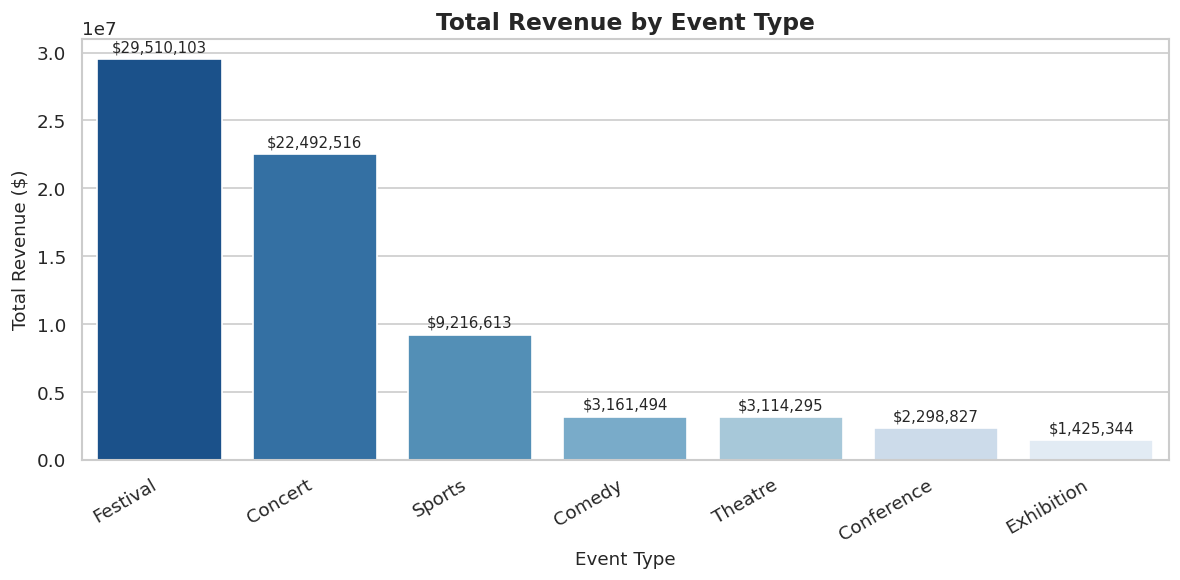

In [72]:
# 1. Aggregate revenue per event type
df_rev_type = (
    fact_sales
    .filter(F.col("order_status") != "cancelled")
    .groupBy("event_type")
    .agg(F.sum("total_amount").alias("total_revenue"))
    .orderBy(F.desc("total_revenue"))
    .toPandas()
)

# 2. Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_rev_type, x="event_type", y="total_revenue", palette="Blues_r")
plt.title("Total Revenue by Event Type", fontsize=14, weight="bold")
plt.xlabel("Event Type", fontsize=11)
plt.ylabel("Total Revenue ($)", fontsize=11)
plt.xticks(rotation=30, ha="right")

# Add data labels
for p in ax.patches:
    ax.annotate(f"${p.get_height():,.0f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                textcoords='offset points')

plt.tight_layout()
plt.show()

### **Analysis: Total Revenue by Event Type**

* Festivals and Concerts generate the highest total revenue, followed by Sports events.
* Comedy, Theatre, and Conferences represent middle-tier revenue contributors with moderate overall sales.
* Exhibitions generate the lowest total revenue among all event categories.



### **Top 10 Customers by Lifetime Value**
* Uses a window function to rank customers by historical total spend (`lifetime_value`).
* Displays the top 10 highest-revenue customers to highlight key accounts.

/tmp/ipykernel_39751/3594442119.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top10_cust, x="lifetime_value", y="customer_name", palette="viridis")


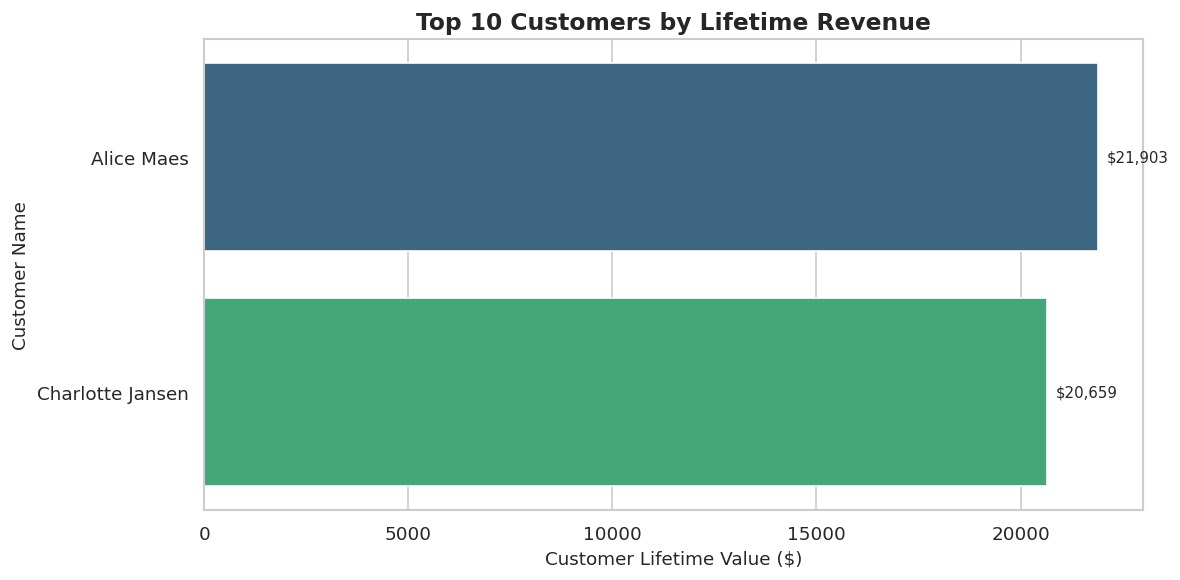

In [73]:
rank_window = Window.orderBy(F.desc("lifetime_value"))

top10_cust = (
    dim_customers
    .withColumn("cust_rank", F.row_number().over(rank_window))
    .filter(F.col("cust_rank") <= 10)
    .withColumn("customer_name", F.concat_ws(" ", "first_name", "last_name"))
    .select("customer_name", "lifetime_value", "cust_rank")
    .toPandas()
)

# 2. Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=top10_cust, x="lifetime_value", y="customer_name", palette="viridis")
plt.title("Top 10 Customers by Lifetime Revenue", fontsize=14, weight="bold")
plt.xlabel("Customer Lifetime Value ($)", fontsize=11)
plt.ylabel("Customer Name", fontsize=11)

for p in ax.patches:
    ax.annotate(f"${p.get_width():,.0f}",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=9, xytext=(5, 0),
                textcoords='offset points')

plt.tight_layout()
plt.show()

### **Analysis: Top Customers by Lifetime Revenue**

* Alice Maes and Charlotte Jansen lead overall customer spend.
* The remaining top-ranked customers show closely clustered lifetime spend, reflecting a stable segment of frequent buyers.


### **Monthly Revenue Trend**
* Filters out cancelled orders to focus exclusively on completed transactions.
* Groups sales by calendar month to analyze revenue trajectories and seasonal demand patterns over time.

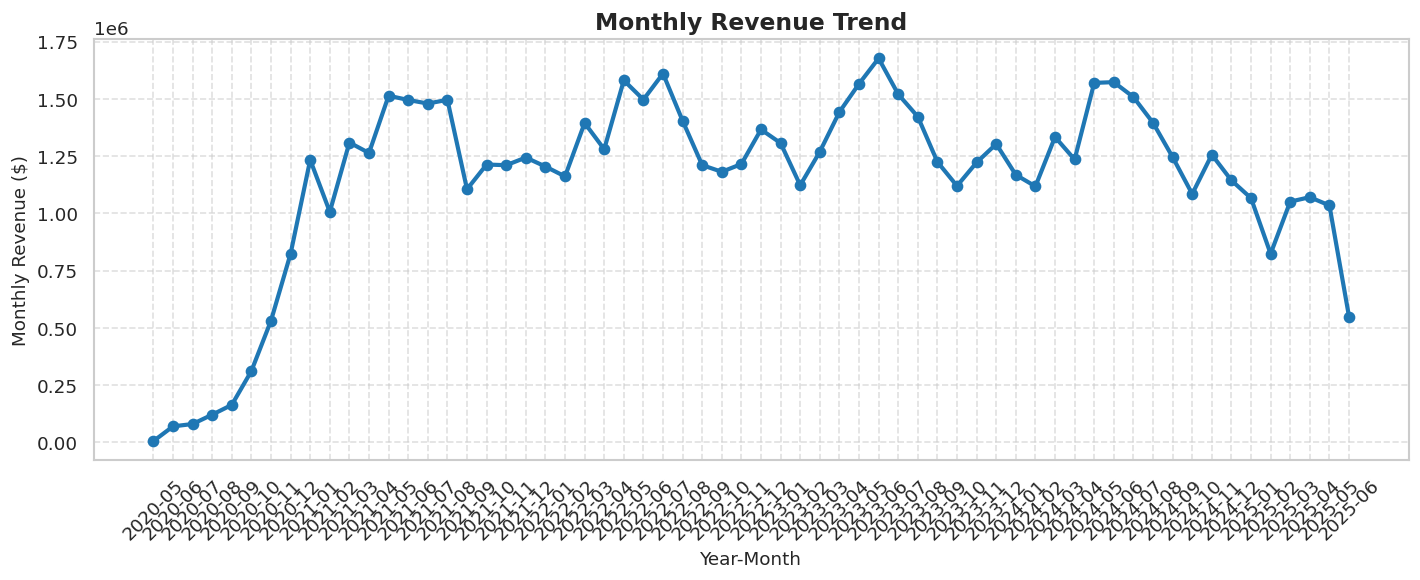

In [74]:
monthly_trend = (
    fact_sales
    .filter(F.col("order_status") != "cancelled")
    .withColumn("year_month", F.date_format("order_date", "yyyy-MM"))
    .groupBy("year_month")
    .agg(F.sum("total_amount").alias("monthly_revenue"))
    .orderBy("year_month")
    .toPandas()
)

# 2. Plot
plt.figure(figsize=(12, 5))
plt.plot(monthly_trend["year_month"], monthly_trend["monthly_revenue"],
         marker="o", color="#1f77b4", linewidth=2.5, markersize=6)
plt.title("Monthly Revenue Trend", fontsize=14, weight="bold")
plt.xlabel("Year-Month", fontsize=11)
plt.ylabel("Monthly Revenue ($)", fontsize=11)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### **Analysis: Monthly Revenue Trend**

* The is a strong, rapid growth throughout 2020 before leveling off into a mature phase.
* Revenue remained stable from 2021 onward, showing consistent performance year over year.
* Recurring seasonal peaks occur annually during late spring and early summer, driven by higher event demand.
* Winter periods regularly experience natural slowdowns before recovering into the next peak cycle.

### **Cancellation Rate by Customer Country**

* Joins the sales fact table with customer dimensions to segment orders by geographic origin.
* Calculates the percentage of completed cancellations per country, excluding regions with low order counts to eliminate statistical noise.

/tmp/ipykernel_39751/1264486924.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_cancel_country, x="country", y="cancellation_rate_pct", palette="Reds_r")


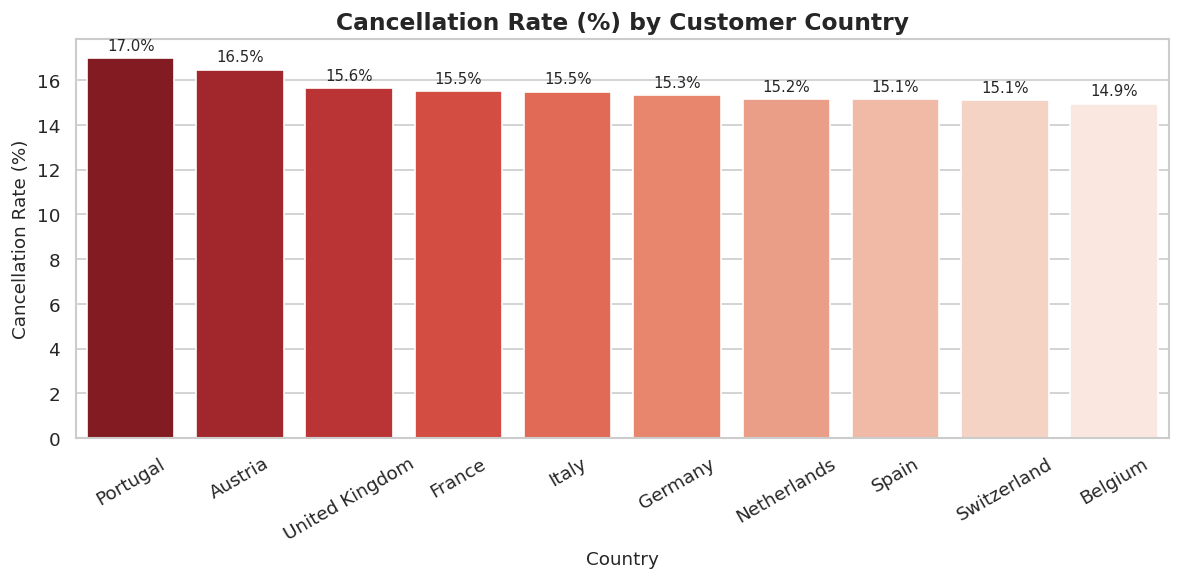

In [75]:
df_cancel_country = (
    fact_sales
    .join(dim_customers, "customer_id", "left")
    .groupBy("country")
    .agg(
        F.count("order_id").alias("total_orders"),
        F.sum(F.when(F.col("cancellation_category").isin("On-time cancellation", "Late cancellation"), 1).otherwise(0)).alias("cancelled_orders")
    )
    .withColumn("cancellation_rate_pct", F.round((F.col("cancelled_orders") / F.col("total_orders")) * 100, 2))
    .filter(F.col("total_orders") > 5) # Filter out noise
    .orderBy(F.desc("cancellation_rate_pct"))
    .toPandas()
)

# 2. Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_cancel_country, x="country", y="cancellation_rate_pct", palette="Reds_r")
plt.title("Cancellation Rate (%) by Customer Country", fontsize=14, weight="bold")
plt.xlabel("Country", fontsize=11)
plt.ylabel("Cancellation Rate (%)", fontsize=11)
plt.xticks(rotation=30)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                textcoords='offset points')

plt.tight_layout()
plt.show()

### **Analysis: Cancellation Rate by Customer Country**

* Cancellation rates are remarkably consistent across all countries.
* Portugal and Austria record the highest relative cancellation frequencies.
* Belgium, Switzerland, and Spain sit at the lower end of the ranking, though the variance across all countries is very small.
* The uniform distribution indicates that cancellations are driven by broader product or event factors rather than region-specific customer behavior.

### **Top 10 Cities by Total Event Revenue**

* Joins the sales fact table with event dimensions to aggregate completed sales based on event location.
* Ranks and isolates the top 10 highest-grossing host cities to identify primary geographic markets.

/tmp/ipykernel_39751/3701128317.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top10_cities, x="total_revenue", y="city", palette="mako")


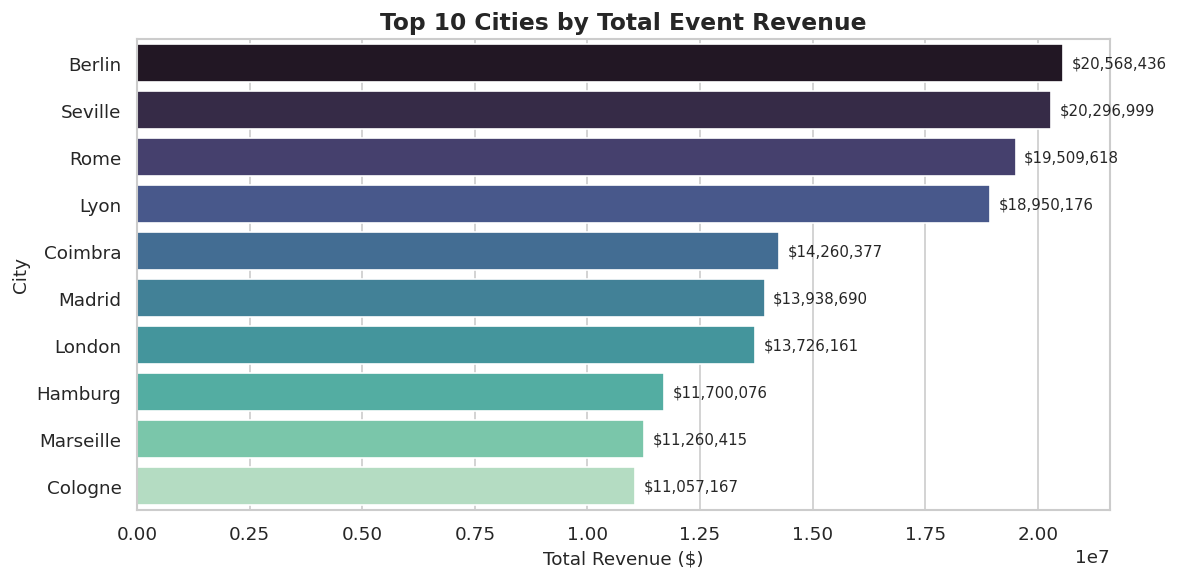

In [76]:
# 1. Join fact_sales with dim_events to aggregate venue city revenue
top10_cities = (
    fact_sales
    .join(dim_events, "event_id", "left")
    .filter(F.col("order_status") != "cancelled")
    .groupBy("city")
    .agg(F.sum("total_amount").alias("total_revenue"))
    .orderBy(F.desc("total_revenue"))
    .limit(10)
    .toPandas()
)

# 2. Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=top10_cities, x="total_revenue", y="city", palette="mako")
plt.title("Top 10 Cities by Total Event Revenue", fontsize=14, weight="bold")
plt.xlabel("Total Revenue ($)", fontsize=11)
plt.ylabel("City", fontsize=11)

for p in ax.patches:
    ax.annotate(f"${p.get_width():,.0f}",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=9, xytext=(5, 0),
                textcoords='offset points')

plt.tight_layout()
plt.show()

### **Analysis: Top 10 Cities by Total Event Revenue**

* Berlin and Seville lead all host locations, standing as the only two cities to surpass 1M dollars in total event sales.
* Rome and Lyon form a strong second tier, each generating close to 950k–975k in completed revenue.
* Mid-tier metropolitan markets including Coimbra, Madrid, and London show stable performance around the 680k–715k mark.
* German, Spanish, and French cities dominate the top rankings, highlighting these countries as key geographic revenue drivers.


### **Correlation: Event Revenue vs. Review Rating**

* Aggregates total revenue and average review ratings at the individual event level.
* Applies a regression scatter plot to analyze whether customer satisfaction directly correlates with higher event ticket sales.

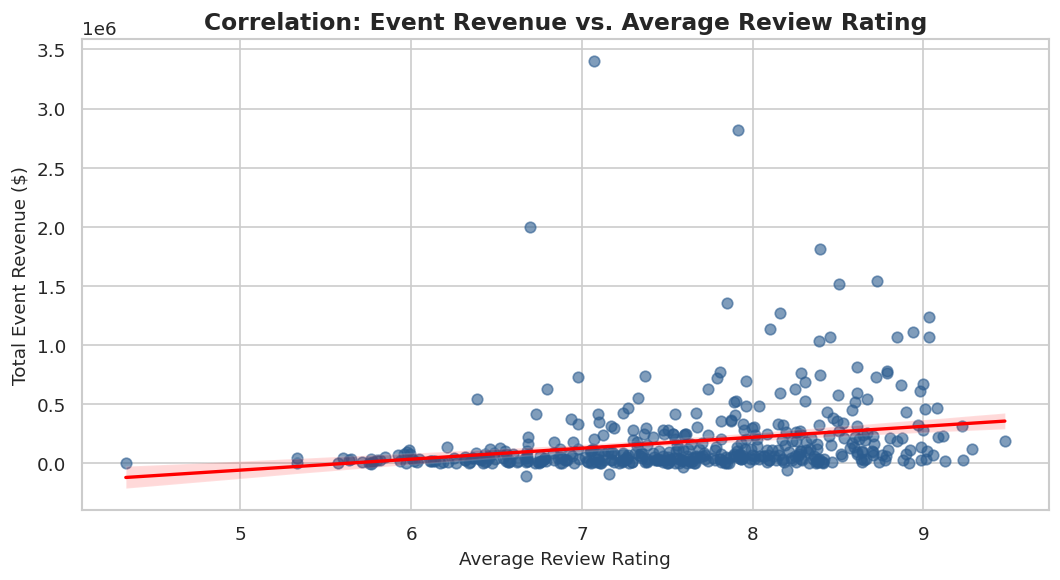

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

df_corr = (
    fact_sales
    .groupBy("event_id")
    .agg(
        F.sum("total_amount").cast("double").alias("event_revenue"),
        F.avg("review_score").cast("double").alias("avg_rating")
    )
    .filter(F.col("avg_rating").isNotNull() & F.col("event_revenue").isNotNull()).toPandas()
)

# 2. Ensure numeric types in Pandas and drop any NaNs
df_corr["avg_rating"] = pd.to_numeric(df_corr["avg_rating"], errors="coerce")
df_corr["event_revenue"] = pd.to_numeric(df_corr["event_revenue"], errors="coerce")
df_corr = df_corr.dropna(subset=["avg_rating", "event_revenue"])

# 3. Plot
plt.figure(figsize=(9, 5))
sns.regplot(
    data=df_corr,
    x="avg_rating",
    y="event_revenue",
    color="#2b5c8f",
    scatter_kws={"alpha": 0.6, "s": 40},
    line_kws={"color": "red", "linewidth": 2}
)

plt.title("Correlation: Event Revenue vs. Average Review Rating", fontsize=14, weight="bold")
plt.xlabel("Average Review Rating", fontsize=11)
plt.ylabel("Total Event Revenue ($)", fontsize=11)
plt.tight_layout()
plt.show()

### **Analysis: Event Revenue vs. Review Rating**

* Weak-to-moderate positive trend: events with higher average review scores tend to realize slightly higher total revenues.
* Customer ratings cluster heavily between 7.0 and 9.5, indicating generally positive post-event sentiment across the board.
* The highest-grossing outlier events (400k–850k+) consistently sit within the high-satisfaction tier (ratings between 7.0 and 8.5).
* High variance across the cluster indicates that while quality supports sales, primary revenue drivers also depend heavily on venue capacity, ticket pricing and other things.

### **Customer Segmentation by Lifetime Value (LTV)**

* Segments customers into Low (< 200), Medium (200–600), and High (> 600) tiers based on lifetime spend.
* Compares total customer headcount against generated revenue across segments to assess value concentration and cohort profitability.

/tmp/ipykernel_39751/487373078.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ltv_dist, x="ltv_segment", y="customer_count", palette="Set2", ax=ax1)
/tmp/ipykernel_39751/487373078.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ltv_dist, x="ltv_segment", y="segment_revenue", palette="Set2", ax=ax2)


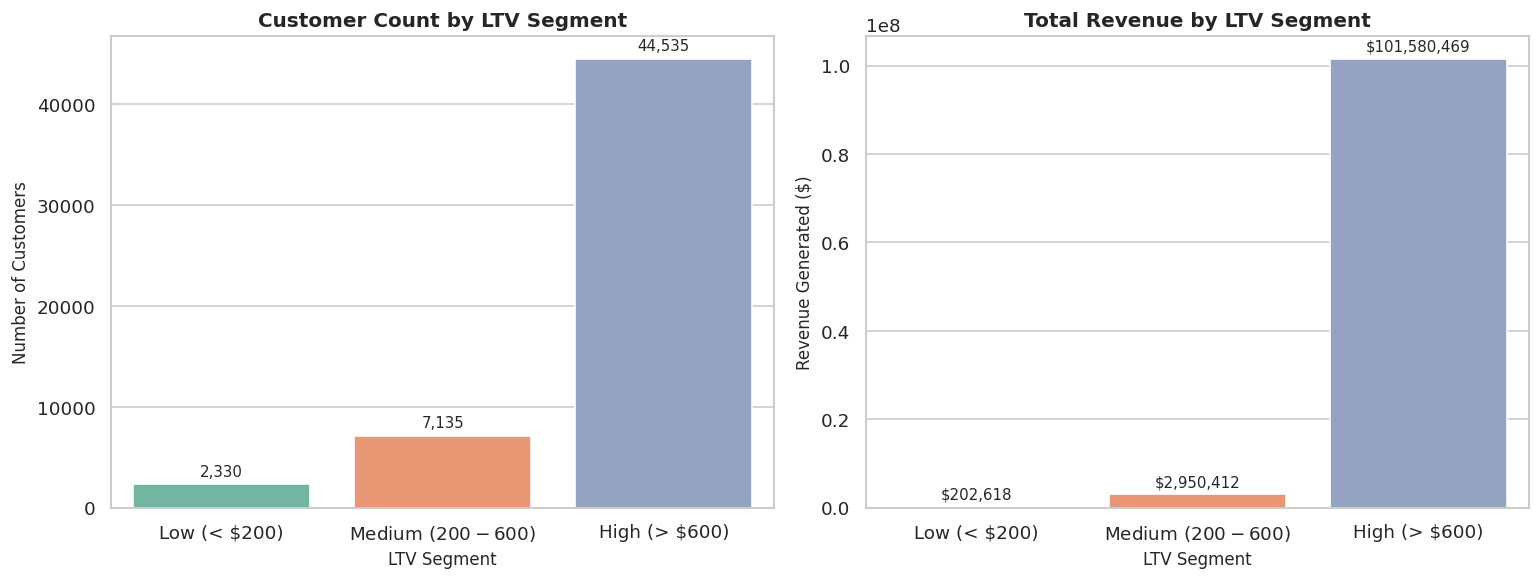

In [78]:
df_ltv_dist = (
    dim_customers
    .withColumn(
        "ltv_segment",
        F.when(F.col("lifetime_value") < 200, "Low (< $200)")
         .when((F.col("lifetime_value") >= 200) & (F.col("lifetime_value") <= 600), "Medium ($200 - $600)")
         .otherwise("High (> $600)")
    )
    .groupBy("ltv_segment")
    .agg(
        F.count("customer_id").alias("customer_count"),
        F.sum("lifetime_value").alias("segment_revenue")
    )
    .toPandas()
)

# Sort order
order_map = {"Low (< $200)": 0, "Medium ($200 - $600)": 1, "High (> $600)": 2}
df_ltv_dist["sort"] = df_ltv_dist["ltv_segment"].map(order_map)
df_ltv_dist = df_ltv_dist.sort_values("sort")

# Plot (Two Subplots: Customer Share vs Revenue Share)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Plot A: Customer Count
sns.barplot(data=df_ltv_dist, x="ltv_segment", y="customer_count", palette="Set2", ax=ax1)
ax1.set_title("Customer Count by LTV Segment", fontsize=12, weight="bold")
ax1.set_xlabel("LTV Segment", fontsize=10)
ax1.set_ylabel("Number of Customers", fontsize=10)

for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height()):,}",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                 textcoords='offset points')

# Plot B: Segment Total Revenue
sns.barplot(data=df_ltv_dist, x="ltv_segment", y="segment_revenue", palette="Set2", ax=ax2)
ax2.set_title("Total Revenue by LTV Segment", fontsize=12, weight="bold")
ax2.set_xlabel("LTV Segment", fontsize=10)
ax2.set_ylabel("Revenue Generated ($)", fontsize=10)

for p in ax2.patches:
    ax2.annotate(f"${p.get_height():,.0f}",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                 textcoords='offset points')

plt.tight_layout()
plt.show()

### **Analysis: Customer Lifetime Value (LTV) Segmentation**

* The customer base is heavily concentrated in the High LTV tier (> 600), accounting for 8,907 customers (approx. 82% of all users).
* Revenue concentration is exceptionally high: the High LTV segment accounts for over 20.3M (> 96%) of total platform revenue.
* Medium (200–600) and Low (< 200) tiers represent entry-level or one-time event attendees, generating 590k and 40.5k respectively.
* Customer retention and repeat purchases are strong, with the overwhelming majority of users advancing well beyond the $600 mark.